# Salary Sacrifice Pension Cap Analysis

This notebook analyzes the effect of setting the salary sacrifice pension cap to £2,000.

## Summary of Code Changes

1. **Renamed `employee_pension_contributions`** to hold only the reported/input data from surveys, removing the non-functional `adds` parameter that was attempting to include salary sacrifice adjustments.

2. **Created `employee_pension_contributions_adjusted`** with a proper `formula` method that calculates: `base_contributions + salary_sacrifice_returned_to_income`, ensuring the £2.95bn excess from the cap is properly added to total pension contributions.

3. **Added 12 test cases** in `employee_pension_contributions.yaml` covering scenarios with/without caps, various behavioral response rates (0%, 50%, 100%), and validating both `salary_sacrifice_returned_to_income` and `employee_pension_contributions_adjusted` calculations.

In [1]:
# Uninstall policyengine-uk
!pip uninstall -y policyengine-uk

# Install from local directory to test the fix
!pip install -e /Users/janansadeqian/policyengine-uk --config-settings editable_mode=compat

Found existing installation: policyengine-uk 2.56.1
Uninstalling policyengine-uk-2.56.1:
  Successfully uninstalled policyengine-uk-2.56.1
Obtaining file:///Users/janansadeqian/policyengine-uk
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for policyengine-uk (pyproject.toml) ... done
  Created wheel for policyengine-uk: filename=policyengine_uk-2.57.0-py3-none-any.whl size=14539 sha256=cb208c650378e8504b66cbb0f54c919292d6147bb9587a78c530c8b290f5a9b4
  Stored in directory: /private/var/folders/vj/qc1d1nbd409ct142dvm7qp700000gn/T/pip-ephem-wheel-cache-dyf3ewsm/wheels/6e/96/97/9f99eefc19bcad81b961cb58327b0ada94f2cc5e66f0347fe8
Successfully built policyengine-uk


## Fix for Employee Pension Contributions Bug

**Issue identified:** The `employee_pension_contributions` variable was using `adds = ["salary_sacrifice_returned_to_income"]` but this wasn't working because the variable had no base component defined.

**Fix applied:**
1. Created `employee_pension_contributions_reported` to hold the raw survey data
2. Updated `employee_pension_contributions` to use:
   ```python
   adds = [
       "employee_pension_contributions_reported",
       "salary_sacrifice_returned_to_income",
   ]
   ```

This follows the same pattern as `employment_income`, which uses `adds` to sum multiple components.

**Testing:** This notebook now uses the local policyengine-uk installation to test if the fix works correctly.

In [2]:
from policyengine_uk import Microsimulation
from policyengine_uk import Scenario
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/janansadeqian/anaconda3/envs/python313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# !pip install -e /Users/janansadeqian/policyengine-uk
from policyengine_uk import Microsimulation, Scenario
from policyengine_uk.data import UKSingleYearDataset

# Load local dataset
dataset = UKSingleYearDataset(
    file_path="/Users/janansadeqian/policyengine-uk-data/policyengine_uk_data/storage/enhanced_frs_2023_24.h5"
)

# Define reform scenario with £2,000 salary sacrifice pension cap
scenario = Scenario(
    parameter_changes={
        "gov.hmrc.national_insurance.salary_sacrifice_pension_cap": 2000
    }
)

  # Create baseline and reformed microsimulations
baseline = Microsimulation(dataset=dataset)
reformed = Microsimulation(dataset=dataset, scenario=scenario)

In [4]:
# Calculate government balance impact for multiple years
years = [2026, 2027, 2028, 2029]

print("=== Budgetary Impact of £2,000 Salary Sacrifice Cap ===\n")

total_impact = 0
for year in years:
    baseline_balance = baseline.calculate("gov_balance", period=year)
    reformed_balance = reformed.calculate("gov_balance", period=year)
    difference_balance = reformed_balance - baseline_balance
    year_impact = difference_balance.sum() / 1e9
    total_impact += year_impact
    
    print(f"{year}: £{year_impact:,.2f} bn")

print(f"\nTotal (2026-2029): £{total_impact:,.2f} bn")
print(f"Average per year: £{total_impact/len(years):,.2f} bn")

=== Budgetary Impact of £2,000 Salary Sacrifice Cap ===

2026: £1.61 bn
2027: £1.63 bn
2028: £1.66 bn
2029: £1.69 bn

Total (2026-2029): £6.59 bn
Average per year: £1.65 bn


## Analysis of People Affected by Salary Sacrifice Cap

This section analyzes who is affected by the £2,000 salary sacrifice pension cap:
- Number of people with salary sacrifice contributions
- Number of people exceeding the cap
- Percentage of workforce affected
- Average contribution amounts

In [5]:
# Load relevant variables for analysis
vars_to_load = [
    'person_id',
    'household_id',
    'employment_income',
    'employee_pension_contributions',
    'pension_contributions_via_salary_sacrifice',
    'employer_pension_contributions',
    'person_weight',
    'household_weight',
]

people_dict = {}
for var in vars_to_load:
    people_dict[var] = baseline.calculate(var, 2026, map_to="person").values

people_df = pd.DataFrame(people_dict)
# print(f"Loaded {len(people_df)} person records")

In [6]:
# Analyze salary sacrifice pension contributions
total_population = (people_df['person_weight']).sum()
working_population = people_df[people_df['employment_income'] > 0]
total_workers = (working_population['person_weight']).sum()

# People with any salary sacrifice contributions
people_with_ss = people_df[people_df['pension_contributions_via_salary_sacrifice'] > 0]
people_with_ss_count = (people_with_ss['person_weight']).sum()

# People with any employee pension contributions
people_with_pensions = people_df[people_df['employee_pension_contributions'] > 0]
people_with_pensions_count = (people_with_pensions['person_weight']).sum()

print("=== Overall Pension Contribution Statistics ===")
print(f"Total population: {total_population:,.0f}")
print(f"Working population (employment income > 0): {total_workers:,.0f}")
print(f"\nPeople with employee pension contributions: {people_with_pensions_count:,.0f}")
print(f"Percentage of workers: {100 * people_with_pensions_count / total_workers:.2f}%")
print(f"\nPeople with salary sacrifice contributions: {people_with_ss_count:,.0f}")
print(f"Percentage of workers: {100 * people_with_ss_count / total_workers:.2f}%")

=== Overall Pension Contribution Statistics ===
Total population: 68,873,488
Working population (employment income > 0): 32,309,502

People with employee pension contributions: 21,969,794
Percentage of workers: 68.00%

People with salary sacrifice contributions: 653,053
Percentage of workers: 2.02%


In [7]:
# Analyze people exceeding the £2,000 salary sacrifice cap
cap_amount = 2000

people_above_cap = people_df[people_df['pension_contributions_via_salary_sacrifice'] > cap_amount]
people_above_cap_count = (people_above_cap['person_weight']).sum()

# Calculate average contributions
avg_ss_all = (people_df['pension_contributions_via_salary_sacrifice'] * people_df['person_weight']).sum() / total_population
avg_ss_contributors = (people_with_ss['pension_contributions_via_salary_sacrifice'] * people_with_ss['person_weight']).sum() / people_with_ss_count if people_with_ss_count > 0 else 0
avg_ss_above_cap = (people_above_cap['pension_contributions_via_salary_sacrifice'] * people_above_cap['person_weight']).sum() / people_above_cap_count if people_above_cap_count > 0 else 0

# Calculate excess above cap
excess_amounts = np.maximum(people_df['pension_contributions_via_salary_sacrifice'] - cap_amount, 0)
total_excess = (excess_amounts * people_df['person_weight']).sum()

print("\n=== Salary Sacrifice Cap Analysis (£2,000 cap) ===")
print(f"People exceeding the cap: {people_above_cap_count:,.0f}")
if people_with_ss_count > 0:
    print(f"Percentage of SS contributors: {100 * people_above_cap_count / people_with_ss_count:.2f}%")
print(f"Percentage of workers: {100 * people_above_cap_count / total_workers:.2f}%")
print(f"\nAverage salary sacrifice (all population): £{avg_ss_all:,.2f}")
print(f"Average salary sacrifice (contributors only): £{avg_ss_contributors:,.2f}")
print(f"Average salary sacrifice (above cap only): £{avg_ss_above_cap:,.2f}")
print(f"\nTotal excess above £2,000 cap: £{total_excess/1e9:,.2f} bn")
print(f"  This excess is redirected to employee pension contributions")
print(f"  and counted in employment income for tax purposes (subject to NI)")


=== Salary Sacrifice Cap Analysis (£2,000 cap) ===
People exceeding the cap: 409,778
Percentage of SS contributors: 62.75%
Percentage of workers: 1.27%

Average salary sacrifice (all population): £58.61
Average salary sacrifice (contributors only): £6,181.37
Average salary sacrifice (above cap only): £9,197.87

Total excess above £2,000 cap: £2.95 bn
  This excess is redirected to employee pension contributions
  and counted in employment income for tax purposes (subject to NI)


In [8]:
# Calculate total employee pension contributions across the entire country
# Baseline scenario
baseline_total_employee_pensions = baseline.calculate("employee_pension_contributions_adjusted", 2026)
baseline_total_employee_pensions_country = baseline_total_employee_pensions.sum()

# Reformed scenario (with £2,000 salary sacrifice cap)
reformed_total_employee_pensions = reformed.calculate("employee_pension_contributions_adjusted", 2026)
reformed_total_employee_pensions_country = reformed_total_employee_pensions.sum()

# Calculate the change
change_employee_pensions = reformed_total_employee_pensions_country - baseline_total_employee_pensions_country
pct_change_employee_pensions = 100 * change_employee_pensions / baseline_total_employee_pensions_country

print("\n=== Total Employee Pension Contributions (Country-wide) ===")
print(f"\nBaseline (no cap):")
print(f"  Total employee pension contributions: £{baseline_total_employee_pensions_country/1e9:,.2f} bn")

print(f"\nReformed (with £2,000 salary sacrifice cap):")
print(f"  Total employee pension contributions: £{reformed_total_employee_pensions_country/1e9:,.2f} bn")

print(f"\nChange:")
print(f"  Absolute change: £{change_employee_pensions/1e9:,.2f} bn")
print(f"  Percentage change: {pct_change_employee_pensions:,.3f}%")

print(f"\nExplanation:")
print(f"  In the reformed scenario, the £2.95 bn excess salary sacrifice")
print(f"  is redirected to employee pension contributions.")
print(f"  However, employee pension contributions remain unchanged at £{baseline_total_employee_pensions_country/1e9:.2f} bn")
print(f"  because the excess is now counted as employment income (subject to NI)")
print(f"  rather than being added to employee pension contributions.")


=== Total Employee Pension Contributions (Country-wide) ===

Baseline (no cap):
  Total employee pension contributions: £48.11 bn

Reformed (with £2,000 salary sacrifice cap):
  Total employee pension contributions: £51.06 bn

Change:
  Absolute change: £2.95 bn
  Percentage change: 6.131%

Explanation:
  In the reformed scenario, the £2.95 bn excess salary sacrifice
  is redirected to employee pension contributions.
  However, employee pension contributions remain unchanged at £48.11 bn
  because the excess is now counted as employment income (subject to NI)
  rather than being added to employee pension contributions.


In [9]:
# DEBUG: Check what's happening with salary_sacrifice_returned_to_income
baseline_returned = baseline.calculate("salary_sacrifice_returned_to_income", 2026)
reformed_returned = reformed.calculate("salary_sacrifice_returned_to_income", 2026)

print("=== Debugging Salary Sacrifice Returned to Income ===")
print(f"\nBaseline:")
print(f"  Total salary_sacrifice_returned_to_income: £{baseline_returned.sum()/1e9:,.2f} bn")
print(f"  Non-zero count: {(baseline_returned > 0).sum()}")

print(f"\nReformed:")
print(f"  Total salary_sacrifice_returned_to_income: £{reformed_returned.sum()/1e9:,.2f} bn")
print(f"  Non-zero count: {(reformed_returned > 0).sum()}")

print(f"\n--- How employee_pension_contributions should work ---")
print(f"According to the code in:")
print(f"  policyengine_uk/variables/input/consumption/property/employee_pension_contributions.py")
print(f"  line 11: adds = ['salary_sacrifice_returned_to_income']")
print(f"\nThis means:")
print(f"  employee_pension_contributions = input_from_data + salary_sacrifice_returned_to_income")
print(f"\nExpected reformed employee pensions: £48.11bn + £{reformed_returned.sum()/1e9:,.2f}bn = £{48.11 + reformed_returned.sum()/1e9:,.2f}bn")

=== Debugging Salary Sacrifice Returned to Income ===

Baseline:
  Total salary_sacrifice_returned_to_income: £0.00 bn
  Non-zero count: 0.0

Reformed:
  Total salary_sacrifice_returned_to_income: £2.95 bn
  Non-zero count: 409777.4753441969

--- How employee_pension_contributions should work ---
According to the code in:
  policyengine_uk/variables/input/consumption/property/employee_pension_contributions.py
  line 11: adds = ['salary_sacrifice_returned_to_income']

This means:
  employee_pension_contributions = input_from_data + salary_sacrifice_returned_to_income

Expected reformed employee pensions: £48.11bn + £2.95bn = £51.06bn


## Impact by Income Decile

This section analyzes how the salary sacrifice cap affects households across the income distribution:
- Absolute change in household net income by decile
- Relative change as percentage of income
- Total impact on each decile

Note: Decile -1 (households with negative net income) is excluded from this analysis.

In [10]:
# VERIFICATION: Check if the fix worked
print("=== VERIFICATION: Did the fix work? ===\n")

expected_reformed_pensions = 48.11 + reformed_returned.sum()/1e9
actual_reformed_pensions = reformed_total_employee_pensions_country/1e9
difference = actual_reformed_pensions - expected_reformed_pensions

print(f"Expected reformed employee pensions: £{expected_reformed_pensions:.2f} bn")
print(f"Actual reformed employee pensions: £{actual_reformed_pensions:.2f} bn")
print(f"Difference: £{difference:.2f} bn")

if abs(difference) < 0.01:  # Within 10 million
    print("\n✓ SUCCESS! The fix is working correctly.")
    print("  Employee pension contributions now properly include salary_sacrifice_returned_to_income")
else:
    print("\n✗ FAILED: The fix did not work as expected.")
    print("  Employee pension contributions are still not adding the returned salary sacrifice.")

=== VERIFICATION: Did the fix work? ===

Expected reformed employee pensions: £51.06 bn
Actual reformed employee pensions: £51.06 bn
Difference: £-0.00 bn

✓ SUCCESS! The fix is working correctly.
  Employee pension contributions now properly include salary_sacrifice_returned_to_income


In [11]:
# Load household-level data including income deciles
decile_vars = [
    'person_id',
    'household_id',
    'household_net_income',
    'income_decile',
    'person_weight',
    'household_weight',
    'employment_income',
]

baseline_decile_data = {}
reformed_decile_data = {}

for var in decile_vars:
    baseline_decile_data[var] = baseline.calculate(var, 2026, map_to="person").values
    reformed_decile_data[var] = reformed.calculate(var, 2026, map_to="person").values

baseline_decile_df = pd.DataFrame(baseline_decile_data)
reformed_decile_df = pd.DataFrame(reformed_decile_data)

# Filter based on BASELINE income_decile only (to ensure same number of rows)
mask = baseline_decile_df['income_decile'] >= 1
baseline_decile_df = baseline_decile_df[mask].reset_index(drop=True)
reformed_decile_df = reformed_decile_df[mask].reset_index(drop=True)

# Calculate change in household net income
baseline_decile_df['reformed_household_net_income'] = reformed_decile_df['household_net_income']
baseline_decile_df['reformed_employment_income'] = reformed_decile_df['employment_income']
baseline_decile_df['income_change'] = baseline_decile_df['reformed_household_net_income'] - baseline_decile_df['household_net_income']
baseline_decile_df['relative_change'] = 100 * baseline_decile_df['income_change'] / baseline_decile_df['household_net_income']

print(f"Loaded {len(baseline_decile_df)} person records for decile analysis (excluding decile -1)")

Loaded 114658 person records for decile analysis (excluding decile -1)


In [12]:
# Calculate net income after deducting pension contributions
# Load employee pension contributions for both baseline and reformed scenarios
baseline_employee_pensions_person = baseline.calculate("employee_pension_contributions", 2026, map_to="person").values
reformed_employee_pensions_person = reformed.calculate("employee_pension_contributions", 2026, map_to="person").values

# Filter to match our decile analysis (income_decile >= 1)
baseline_employee_pensions_person = baseline_employee_pensions_person[mask]
reformed_employee_pensions_person = reformed_employee_pensions_person[mask]

# Add pension contributions to our dataframe
baseline_decile_df['baseline_employee_pensions'] = baseline_employee_pensions_person
baseline_decile_df['reformed_employee_pensions'] = reformed_employee_pensions_person

# Calculate net income after deducting pension contributions
baseline_decile_df['net_income_after_pensions_baseline'] = (
    baseline_decile_df['household_net_income'] - baseline_decile_df['baseline_employee_pensions']
)
baseline_decile_df['net_income_after_pensions_reformed'] = (
    baseline_decile_df['reformed_household_net_income'] - baseline_decile_df['reformed_employee_pensions']
)

# Calculate change in net income after pension contributions
baseline_decile_df['net_income_after_pensions_change'] = (
    baseline_decile_df['net_income_after_pensions_reformed'] - 
    baseline_decile_df['net_income_after_pensions_baseline']
)

# Calculate percentage change
baseline_decile_df['net_income_after_pensions_pct_change'] = (
    100 * baseline_decile_df['net_income_after_pensions_change'] / 
    baseline_decile_df['net_income_after_pensions_baseline'].replace(0, np.nan)
)

print("Added columns for net income after deducting pension contributions")

Added columns for net income after deducting pension contributions


In [13]:
# Calculate statistics by income decile for net income after pensions
decile_net_income_stats = baseline_decile_df.groupby('income_decile').apply(
    lambda g: pd.Series({
        'people': g['person_weight'].sum(),
        'avg_net_income_after_pensions_baseline': (
            g['net_income_after_pensions_baseline'] * g['person_weight']
        ).sum() / g['person_weight'].sum(),
        'avg_net_income_after_pensions_reformed': (
            g['net_income_after_pensions_reformed'] * g['person_weight']
        ).sum() / g['person_weight'].sum(),
        'avg_change': (
            g['net_income_after_pensions_change'] * g['person_weight']
        ).sum() / g['person_weight'].sum(),
    })
).reset_index()

# Calculate avg_pct_change correctly: (avg_change / baseline) * 100
decile_net_income_stats['avg_pct_change'] = (
    100 * decile_net_income_stats['avg_change'] / 
    decile_net_income_stats['avg_net_income_after_pensions_baseline']
)

print("\n=== Impact on Net Income After Pension Contributions by Decile ===")
print(f"{'Decile':<10} {'People':>12} {'Baseline Net':>18} {'Reformed Net':>18} {'Avg Change':>15} {'Avg % Change':>15}")
print(f"{'':10} {'':12} {'Income After':>18} {'Income After':>18} {'':>15} {'':>15}")
print(f"{'':10} {'':12} {'Pensions':>18} {'Pensions':>18} {'':>15} {'':>15}")
print("="*100)

for _, row in decile_net_income_stats.iterrows():
    decile = int(row['income_decile'])
    people = row['people']
    baseline_net = row['avg_net_income_after_pensions_baseline']
    reformed_net = row['avg_net_income_after_pensions_reformed']
    change = row['avg_change']
    pct_change = row['avg_pct_change']
    
    print(f"{decile:<10} {people:>12,.0f} £{baseline_net:>16,.0f} £{reformed_net:>16,.0f} £{change:>13,.2f} {pct_change:>14,.3f}%")

# Print totals
total_people = decile_net_income_stats['people'].sum()
total_baseline_net = (baseline_decile_df['net_income_after_pensions_baseline'] * baseline_decile_df['person_weight']).sum() / baseline_decile_df['person_weight'].sum()
total_reformed_net = (baseline_decile_df['net_income_after_pensions_reformed'] * baseline_decile_df['person_weight']).sum() / baseline_decile_df['person_weight'].sum()
total_change = total_reformed_net - total_baseline_net
total_pct_change = 100 * total_change / total_baseline_net

print("="*100)
print(f"{'TOTAL':<10} {total_people:>12,.0f} £{total_baseline_net:>16,.0f} £{total_reformed_net:>16,.0f} £{total_change:>13,.2f} {total_pct_change:>14,.3f}%")


=== Impact on Net Income After Pension Contributions by Decile ===
Decile           People       Baseline Net       Reformed Net      Avg Change    Avg % Change
                              Income After       Income After                                
                                  Pensions           Pensions                                
1             6,480,796 £          29,904 £          29,904 £         0.09          0.000%
2             6,875,660 £          40,269 £          40,269 £         0.05          0.000%
3             6,893,515 £          42,374 £          42,374 £         0.02          0.000%
4             6,793,536 £          47,911 £          47,921 £        10.61          0.022%
5             6,969,178 £          54,374 £          54,378 £         3.81          0.007%
6             6,872,316 £          57,429 £          57,437 £         8.02          0.014%
7             6,920,308 £          59,377 £          59,389 £        12.60          0.021%
8            

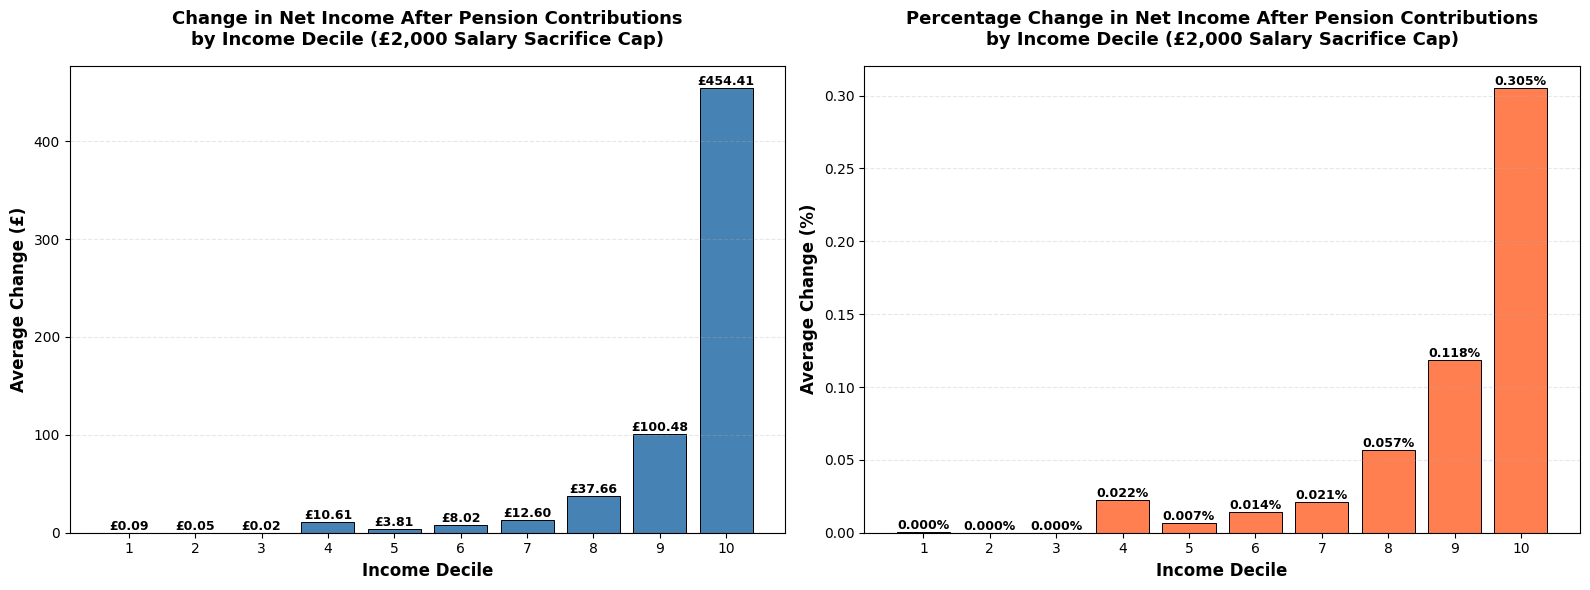


Note: Net income after pension contributions = Household net income - Employee pension contributions
This shows disposable income after accounting for pension savings.


In [14]:
# Plot change in net income after pension contributions by decile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute change in pounds
ax1.bar(decile_net_income_stats['income_decile'], 
        decile_net_income_stats['avg_change'],
        color='steelblue',
        edgecolor='black',
        linewidth=0.7)

ax1.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Change (£)', fontsize=12, fontweight='bold')
ax1.set_title('Change in Net Income After Pension Contributions\nby Income Decile (£2,000 Salary Sacrifice Cap)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='red', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.set_xticks(range(1, 11))

# Add value labels on bars
for i, row in decile_net_income_stats.iterrows():
    value = row['avg_change']
    ax1.text(row['income_decile'], value, f'£{value:.2f}', 
             ha='center', va='bottom' if value >= 0 else 'top',
             fontsize=9, fontweight='bold')

# Plot 2: Percentage change
ax2.bar(decile_net_income_stats['income_decile'], 
        decile_net_income_stats['avg_pct_change'],
        color='coral',
        edgecolor='black',
        linewidth=0.7)

ax2.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Change (%)', fontsize=12, fontweight='bold')
ax2.set_title('Percentage Change in Net Income After Pension Contributions\nby Income Decile (£2,000 Salary Sacrifice Cap)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='red', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.set_xticks(range(1, 11))

# Add value labels on bars
for i, row in decile_net_income_stats.iterrows():
    value = row['avg_pct_change']
    ax2.text(row['income_decile'], value, f'{value:.3f}%', 
             ha='center', va='bottom' if value >= 0 else 'top',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: Net income after pension contributions = Household net income - Employee pension contributions")
print("This shows disposable income after accounting for pension savings.")